# 🚀 Prédiction du Churn — Version 3
### Diagnostic Données Synthétiques + Stratégie Adaptée

---
## 🔬 Diagnostic V2 : Pourquoi AUC ~0.59 est le plafond réel

**Problème fondamental identifié : données synthétiques à signal très faible**

L'analyse exhaustive des tables révèle que le CHURN a été assigné **quasi-aléatoirement** lors de la génération :

| Feature | Attendu (vraies données) | Observé (données synthétiques) |
|---------|--------------------------|-------------------------------|
| BONUS_MALUS | Churners = BM plus élevé | Distribution identique (mean 4.74 vs 4.70) |
| PERIODICITE | Mensuel = plus de churn | Taux identique ~17% pour A/S/T/C |
| TYPE_POLICE | Flotte = moins de churn | Quasi-identique (17.5% vs 16.7%) |
| nb_sinistres | Churners = plus de sinistres | Identique (1.17 pour les deux groupes) |
| has_impaye | Churners = plus d'impayés | **Inversé** — churners ont MOINS d'impayés |
| age_client | Signal attendu | Corrélation ≈ 0.007 (nulle) |
| CODE_PRODUIT | Fort différentiel | <2% de différence entre produits |

**Seul vrai signal :** `has_emission` (corr=-0.16) — les polices résiliées avaient moins de quittances générées.

**Conséquence :** AUC ~0.59-0.62 est le **maximum théorique** pour ces données.

**Stratégie V3 :**
1. ✅ Extraire **chaque signal disponible** de façon exhaustive (couvertures, tendances, interactions)
2. ✅ Features croisées et agrégations contextuelles (agent, client multi-polices)
3. ✅ Diversifier les modèles (ExtraTrees, GradBoost, Soft Voting)
4. ✅ Analyse métier : **seuil business** optimisé pour capturer les churners
5. ✅ Documentation complète pour migration vers vraies données


## 📦 0. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      RandomizedSearchCV)
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    f1_score, accuracy_score, precision_score, recall_score,
    average_precision_score, ConfusionMatrixDisplay
)
from sklearn.ensemble import (RandomForestClassifier, StackingClassifier,
                               GradientBoostingClassifier, ExtraTreesClassifier,
                               VotingClassifier)
from sklearn.linear_model import LogisticRegression
from scipy.stats import randint, uniform

import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import BorderlineSMOTE

import shap
import sklearn, imblearn
print('✅ Imports OK')
print(f'   xgboost={xgb.__version__} | lgb={lgb.__version__} | shap={shap.__version__}')
print(f'   sklearn={sklearn.__version__} | imbalanced={imblearn.__version__}')

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


✅ Imports OK
   xgboost=3.2.0 | lgb=4.6.0 | shap=0.49.1
   sklearn=1.7.2 | imbalanced=0.14.1


## 📥 1. Chargement des Données

In [2]:
DATA_PATH = r'C:\Users\LENOVO\Desktop\PFE_\maghrebia\data\raw\\'

dim_police    = pd.read_csv(DATA_PATH + 'DIM_POLICE.csv')
dim_client    = pd.read_csv(DATA_PATH + 'DIM_CLIENT.csv')
dim_agent     = pd.read_csv(DATA_PATH + 'DIM_AGENT.csv')
dim_vehicule  = pd.read_csv(DATA_PATH + 'DIM_VEHICULE.csv')
fact_emission = pd.read_csv(DATA_PATH + 'DWH_FACT_EMISSION.csv')
fact_sinistre = pd.read_csv(DATA_PATH + 'DWH_FACT_SINISTRE.csv')
fact_impaye   = pd.read_csv(DATA_PATH + 'DWH_FACT_IMPAYE.csv')
fact_annul    = pd.read_csv(DATA_PATH + 'DWH_FACT_ANNULATION.csv')

print('Tables chargées :')
for name, dftmp in [('DIM_POLICE',dim_police),('DIM_CLIENT',dim_client),
                  ('FACT_EMISSION',fact_emission),('FACT_SINISTRE',fact_sinistre),
                  ('FACT_IMPAYE',fact_impaye),('FACT_ANNULATION',fact_annul),
                  ('DIM_VEHICULE',dim_vehicule),('DIM_AGENT',dim_agent)]:
    print(f'  {name:<20} : {dftmp.shape[0]:>7,} x {dftmp.shape[1]} cols')


Tables chargées :
  DIM_POLICE           :  30,000 x 16 cols
  DIM_CLIENT           :  30,000 x 13 cols
  FACT_EMISSION        :  65,000 x 33 cols
  FACT_SINISTRE        :   8,000 x 16 cols
  FACT_IMPAYE          :     868 x 16 cols
  FACT_ANNULATION      :   1,273 x 22 cols
  DIM_VEHICULE         :  20,000 x 15 cols
  DIM_AGENT            :     200 x 12 cols


## 🎯 2. Définition de la Cible

In [3]:
# Churn = Resiliee (R) ou Annulee (A)
dim_police['CHURN'] = dim_police['SITUATION'].isin(['R', 'A']).astype(int)

n_churn = dim_police['CHURN'].sum()
n_total = len(dim_police)
print(f'Taux de churn : {dim_police["CHURN"].mean():.1%}')
print(f'  Churned   : {n_churn:,}')
print(f'  Non-churn : {(dim_police["CHURN"]==0).sum():,}')
print(f'  Ratio     : 1:{int((dim_police["CHURN"]==0).sum()/n_churn)}')

n_neg = (dim_police['CHURN']==0).sum()
n_pos = n_churn
scale_pos_weight = n_neg / n_pos
print(f'\nscale_pos_weight (XGBoost) = {scale_pos_weight:.2f}')

print('\nDistribution SITUATION:')
sit_map = {'V':'Valide','S':'Suspendu','R':'Resilie','A':'Annule','T':'Transitoire'}
for sit, cnt in dim_police['SITUATION'].value_counts().items():
    print(f'  {sit} ({sit_map.get(sit,sit):<12}): {cnt:>6,}  ({cnt/n_total:.1%})')


Taux de churn : 16.9%
  Churned   : 5,060
  Non-churn : 24,940
  Ratio     : 1:4

scale_pos_weight (XGBoost) = 4.93

Distribution SITUATION:
  V (Valide      ): 19,483  (64.9%)
  R (Resilie     ):  3,609  (12.0%)
  T (Transitoire ):  3,007  (10.0%)
  S (Suspendu    ):  2,450  (8.2%)
  A (Annule      ):  1,451  (4.8%)


## 🔧 3. Feature Engineering V3 — Extraction Exhaustive

**Nouveautés V3 :** couvertures par garantie, tendances de prime,
features croisées, agrégations agent/client, interactions non-linéaires.


In [4]:
# ── 3.1 Nettoyage Emission ──────────────────────────────────────────────
ANNEE_MIN, ANNEE_MAX = 2018, 2026
fact_clean = fact_emission[
    fact_emission['ANNEE_ECHEANCE'].between(ANNEE_MIN, ANNEE_MAX)
].copy()
removed = len(fact_emission) - len(fact_clean)
print(f'Emission nettoyee : {len(fact_clean):,} quittances ({removed} aberrantes supprimees)')

fact_clean['ETAT_QUIT_NORM'] = fact_clean['ETAT_QUIT'].str.upper().str.strip()

# Indicateur binaire par garantie
for col in ['MT_RC','MT_VOL','MT_DOM','MT_INC','MT_BGL','MT_DOMCOLL','MT_TEL']:
    fact_clean[f'has_{col.lower()}'] = (fact_clean[col] > 0).astype(int)

# ── 3.2 Aggregations Emission ────────────────────────────────────────────
emit_feats = fact_clean.groupby('ID_POLICE').agg(
    nb_quittances       = ('NUM_QUITTANCE',  'count'),
    prime_net_moy       = ('MT_PNET',        'mean'),
    prime_net_sum       = ('MT_PNET',        'sum'),
    prime_net_std       = ('MT_PNET',        'std'),
    prime_net_min       = ('MT_PNET',        'min'),
    prime_net_max       = ('MT_PNET',        'max'),
    prime_ptt_moy       = ('MT_PTT',         'mean'),
    commission_moy      = ('MT_COMMISSION',  'mean'),
    commission_sum      = ('MT_COMMISSION',  'sum'),
    bonus_malus_moy     = ('BONUS_MALUS',    'mean'),
    bonus_malus_max     = ('BONUS_MALUS',    'max'),
    bonus_malus_min     = ('BONUS_MALUS',    'min'),
    # Couvertures presentes
    has_rc              = ('has_mt_rc',      'max'),
    has_vol             = ('has_mt_vol',     'max'),
    has_dom             = ('has_mt_dom',     'max'),
    has_inc             = ('has_mt_inc',     'max'),
    has_bgl             = ('has_mt_bgl',     'max'),
    has_domcoll         = ('has_mt_domcoll', 'max'),
    has_tel             = ('has_mt_tel',     'max'),
    # Temporel
    nb_avenants_max     = ('NUM_AVN',        'max'),
    nb_annees_emission  = ('ANNEE_ECHEANCE', 'nunique'),
    annee_premiere_emit = ('ANNEE_ECHEANCE', 'min'),
    annee_derniere_emit = ('ANNEE_ECHEANCE', 'max'),
    mois_mode_emit      = ('MOIS_ECHEANCE', lambda x: x.mode()[0] if len(x)>0 else 0),
    # SIT patterns
    nb_sit_normal       = ('SIT', lambda x: (x==1).sum()),
    nb_sit_impaye       = ('SIT', lambda x: (x==2).sum()),
    nb_sit_annule_sit   = ('SIT', lambda x: (x==3).sum()),
    nb_sit_resilie      = ('SIT', lambda x: (x==4).sum()),
    # ETAT_QUIT
    nb_quit_payees      = ('ETAT_QUIT_NORM', lambda x: (x=='P').sum()),
    nb_quit_en_cours    = ('ETAT_QUIT_NORM', lambda x: (x=='E').sum()),
    nb_quit_annulees    = ('ETAT_QUIT_NORM', lambda x: (x=='A').sum()),
).reset_index()

# Couvertures reelles par police
cov_cols = ['has_mt_rc','has_mt_vol','has_mt_dom','has_mt_inc',
            'has_mt_bgl','has_mt_domcoll','has_mt_tel']
cov_sums = fact_clean.groupby('ID_POLICE')[cov_cols].max().sum(axis=1).reset_index(name='nb_garanties_reel')
emit_feats = emit_feats.merge(cov_sums, on='ID_POLICE', how='left')

# Ratios
emit_feats['taux_impaye']      = (emit_feats['nb_sit_impaye'] /
                                   emit_feats['nb_quittances'].replace(0, np.nan)).fillna(0)
emit_feats['taux_annule_quit'] = (emit_feats['nb_sit_annule_sit'] /
                                   emit_feats['nb_quittances'].replace(0, np.nan)).fillna(0)
emit_feats['taux_paiement']    = (emit_feats['nb_quit_payees'] /
                                   emit_feats['nb_quittances'].replace(0, np.nan)).fillna(0)
emit_feats['taux_en_cours']    = (emit_feats['nb_quit_en_cours'] /
                                   emit_feats['nb_quittances'].replace(0, np.nan)).fillna(0)
emit_feats['prime_net_std']    = emit_feats['prime_net_std'].fillna(0)
emit_feats['anciennete_emit']  = (emit_feats['annee_derniere_emit'] -
                                   emit_feats['annee_premiere_emit'] + 1).clip(0, 20)
emit_feats['prime_par_avenant'] = (emit_feats['prime_net_sum'] /
                                    emit_feats['nb_avenants_max'].replace(0, np.nan))
emit_feats['prime_par_quit']   = (emit_feats['prime_net_sum'] /
                                   emit_feats['nb_quittances'].replace(0, np.nan))
emit_feats['ratio_commission']  = (emit_feats['commission_sum'] /
                                    emit_feats['prime_net_sum'].replace(0, np.nan)).fillna(0)
emit_feats['prime_variation']  = emit_feats['prime_net_max'] - emit_feats['prime_net_min']
emit_feats['bm_variation']     = emit_feats['bonus_malus_max'] - emit_feats['bonus_malus_min']
emit_feats['has_emission']     = 1

print(f'Features emission V3 : {emit_feats.shape[1]-1} features | {len(emit_feats):,} polices')


Emission nettoyee : 63,625 quittances (1375 aberrantes supprimees)
Features emission V3 : 43 features | 23,786 polices


In [5]:
# ── 3.3 Sinistres ───────────────────────────────────────────────────────
fact_sinistre['delai_declaration'] = (
    pd.to_datetime(fact_sinistre['DATE_DECLARATION'], errors='coerce') -
    pd.to_datetime(fact_sinistre['DATE_SURVENANCE'],  errors='coerce')
).dt.days.clip(0, 365)

sin_feats = fact_sinistre.groupby('ID_POLICE').agg(
    nb_sinistres         = ('NUM_SINISTRE',    'count'),
    mt_evalue_total      = ('MT_EVALUATION',   'sum'),
    mt_paye_total        = ('MT_PAYE',         'sum'),
    mt_evalue_moy        = ('MT_EVALUATION',   'mean'),
    nb_sin_ouverts       = ('ETAT_SINISTRE',   lambda x: (x=='Ouvert').sum()),
    responsabilite_moy   = ('RESPONSABILITE',  'mean'),
    responsabilite_max   = ('RESPONSABILITE',  'max'),
    nb_annees_sin        = ('ANNEE_SURVENANCE', 'nunique'),
    delai_decl_moy       = ('delai_declaration','mean'),
).reset_index()
sin_feats['taux_remboursement'] = (sin_feats['mt_paye_total'] /
                                    sin_feats['mt_evalue_total'].replace(0, np.nan)).fillna(0).clip(0,2)
sin_feats['taux_sin_ouverts']   = (sin_feats['nb_sin_ouverts'] /
                                    sin_feats['nb_sinistres'].replace(0, np.nan)).fillna(0)
sin_feats['ratio_sinistral']    = (sin_feats['mt_evalue_total'] /
                                    sin_feats['mt_paye_total'].replace(0, np.nan)).fillna(0).clip(0,10)
print(f'Features sinistres : {sin_feats.shape[1]-1} features')

# ── 3.4 Impayes ──────────────────────────────────────────────────────────
imp_feats = fact_impaye.groupby('ID_POLICE').agg(
    nb_impayes        = ('NUM_QUITTANCE', 'count'),
    mt_impaye_sum     = ('MT_PTT',        'sum'),
    mt_impaye_moy     = ('MT_PTT',        'mean'),
    mt_impaye_max     = ('MT_PTT',        'max'),
    nb_annees_imp     = ('ANNEE_ECHEANCE','nunique'),
    annee_dernier_imp = ('ANNEE_ECHEANCE','max'),
).reset_index()
print(f'Features impayes  : {imp_feats.shape[1]-1} features')

# ── 3.5 Annulations ──────────────────────────────────────────────────────
fact_annul['delai_annulation'] = (
    pd.to_datetime(fact_annul['DATE_ANNULATION'], errors='coerce') -
    pd.to_datetime(fact_annul['DATE_EMISSION'],   errors='coerce')
).dt.days.clip(0, 730)
ann_feats = fact_annul.groupby('ID_POLICE').agg(
    nb_annulations  = ('NUM_QUITTANCE',   'count'),
    mt_annule_sum   = ('MT_PTT_ANN',      'sum'),
    mt_annule_moy   = ('MT_PTT_ANN',      'mean'),
    nb_nature_ann   = ('NATURE_ANNULATION','nunique'),
    delai_ann_moy   = ('delai_annulation', 'mean'),
).reset_index()
print(f'Features annulations: {ann_feats.shape[1]-1} features')


Features sinistres : 12 features
Features impayes  : 6 features
Features annulations: 5 features


### 3.6 Mean Target Encoding (K-Fold, anti data leakage)

In [6]:
def kfold_target_encoding(df, col, target='CHURN', n_splits=5, smoothing=10):
    """MTE avec K-Fold cross-validation et Bayesian smoothing."""
    global_mean = df[target].mean()
    encoded     = np.zeros(len(df))
    skf         = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for train_idx, val_idx in skf.split(df, df[target]):
        train_fold = df.iloc[train_idx]
        stats      = train_fold.groupby(col)[target].agg(['mean', 'count'])
        stats['smooth'] = (
            (stats['count'] * stats['mean'] + smoothing * global_mean)
            / (stats['count'] + smoothing)
        )
        val_col = df.iloc[val_idx][col]
        encoded[val_idx] = val_col.map(stats['smooth']).fillna(global_mean).values
    return encoded

df = dim_police[['ID_POLICE','ID_CLIENT','ID_AGENT','CODE_PRODUIT','ID_BRANCHE',
                  'TYPE_POLICE','DUREE','PERIODICITE','BONUS_MALUS',
                  'DATE_EFFET','DATE_ECHEANCE','SITUATION','POLRP','CHURN']].copy()

print('Calcul du Mean Target Encoding (K-Fold 5)...')
for col in ['ID_AGENT','CODE_PRODUIT','ID_CLIENT','ID_BRANCHE']:
    key = f'mte_{col.lower()}'
    df[key] = kfold_target_encoding(df, col)
    corr = df[['CHURN', key]].corr().loc['CHURN', key]
    print(f'  {key:<28} corr CHURN : {corr:.4f}')
print('MTE calcule sans data leakage')


Calcul du Mean Target Encoding (K-Fold 5)...
  mte_id_agent                 corr CHURN : 0.0062
  mte_code_produit             corr CHURN : 0.0051
  mte_id_client                corr CHURN : -0.0087
  mte_id_branche               corr CHURN : 0.0004
MTE calcule sans data leakage


### 3.7 Features Temporelles, Véhicule, Client, Agent

In [7]:
NOW = pd.Timestamp('2025-01-01')

df['DATE_EFFET']    = pd.to_datetime(df['DATE_EFFET'],    errors='coerce')
df['DATE_ECHEANCE'] = pd.to_datetime(df['DATE_ECHEANCE'], errors='coerce')

df['annee_debut']       = df['DATE_EFFET'].dt.year
df['mois_debut']        = df['DATE_EFFET'].dt.month
df['anciennete_pol']    = (NOW - df['DATE_EFFET']).dt.days.clip(0, 3650)
df['jours_echeance']    = (df['DATE_ECHEANCE'] - NOW).dt.days.clip(-365, 730)
df['saison_debut']      = ((df['mois_debut'] - 1) // 3 + 1)
df['echeance_proche']   = (df['jours_echeance'].between(0, 90)).astype(int)
df['echeance_depassee'] = (df['jours_echeance'] < 0).astype(int)
df['has_polrp']         = df['POLRP'].notna().astype(int)

period_map = {'A': 1, 'S': 2, 'T': 4, 'C': 12}
df['periodicite_num'] = df['PERIODICITE'].map(period_map).fillna(1)
df['is_flotte']       = (df['TYPE_POLICE'] == 'flotte').astype(int)

# Vehicule
dim_vehicule['DATE_MEC']    = pd.to_datetime(dim_vehicule['DATE_MEC'], errors='coerce')
dim_vehicule['age_vehicule'] = ((NOW - dim_vehicule['DATE_MEC']).dt.days.clip(0, 20000) / 365.25)
dim_vehicule['ratio_valeur'] = (
    dim_vehicule['VALEUR_ACTUELLE'] / dim_vehicule['VALEUR_A_NEUF'].replace(0, np.nan)
).clip(0, 2)
dim_vehicule['valeur_log']   = np.log1p(dim_vehicule['VALEUR_ACTUELLE'].clip(0))
dim_vehicule['puissance_log'] = np.log1p(dim_vehicule['PUISSANCE'].clip(0))
usage_map = {k: i for i, k in enumerate(dim_vehicule['CODE_USAGE'].value_counts().index)}
dim_vehicule['usage_enc'] = dim_vehicule['CODE_USAGE'].map(usage_map).fillna(-1)

veh_feats = dim_vehicule.groupby('ID_POLICE').agg(
    nb_vehicules       = ('ID_VEHICULE',   'count'),
    puissance_moy      = ('PUISSANCE',     'mean'),
    puissance_log_moy  = ('puissance_log', 'mean'),
    age_veh_moy        = ('age_vehicule',  'mean'),
    age_veh_max        = ('age_vehicule',  'max'),
    ratio_val_moy      = ('ratio_valeur',  'mean'),
    valeur_log_moy     = ('valeur_log',    'mean'),
    nb_places_moy      = ('NB_PLACE',      'mean'),
    usage_enc_mode     = ('usage_enc',     lambda x: x.mode()[0] if len(x)>0 else -1),
    genre_enc          = ('GENRE_VEHICULE', lambda x: pd.factorize(x)[0][0] if len(x)>0 else -1),
).reset_index()

# Client
dim_client['DATE_NAISSANCE'] = pd.to_datetime(dim_client['DATE_NAISSANCE'], errors='coerce')
dim_client['age_client']     = ((NOW - dim_client['DATE_NAISSANCE']).dt.days / 365.25).clip(18, 90)
dim_client['is_pm']          = (dim_client['TYPE_PERSONNE'] == 'M').astype(int)
dim_client['sexe_enc']       = pd.factorize(dim_client['SEXE'].fillna('I'))[0]
dim_client['natp_enc']       = pd.factorize(dim_client['NATP'].fillna('TN'))[0]
dim_client['has_email']      = dim_client['EMAIL'].notna().astype(int)
client_feats = dim_client[['ID_CLIENT','age_client','is_pm','sexe_enc','natp_enc','has_email']].copy()

# Agent
dim_agent['agent_actif'] = (dim_agent['ETAT_AGENT'] == 'A').astype(int)
dim_agent['groupe_enc']  = pd.factorize(dim_agent['GROUPE_AGENT'].fillna('IND'))[0]
dim_agent['type_enc']    = pd.factorize(dim_agent['TYPE_AGENT'].fillna('C'))[0]
agent_feats = dim_agent[['ID_AGENT','agent_actif','groupe_enc','type_enc']].copy()

print('Features temporelles, vehicule, client, agent pretes')


Features temporelles, vehicule, client, agent pretes


### 3.8 Assemblage Final + Features Croisées

In [8]:
df = df.merge(client_feats, on='ID_CLIENT', how='left')
df = df.merge(agent_feats,  on='ID_AGENT',  how='left')
df = df.merge(veh_feats,    on='ID_POLICE', how='left')
df = df.merge(emit_feats,   on='ID_POLICE', how='left')
df = df.merge(sin_feats,    on='ID_POLICE', how='left')
df = df.merge(imp_feats,    on='ID_POLICE', how='left')
df = df.merge(ann_feats,    on='ID_POLICE', how='left')

# NaN -> 0 pour les tables de faits (absence = 0 activite)
for feats_df in [emit_feats, sin_feats, imp_feats, ann_feats]:
    zero_cols = [c for c in feats_df.columns if c != 'ID_POLICE']
    df[zero_cols] = df[zero_cols].fillna(0)

# ── Features croisees (interactions) ──────────────────────────────────────
df['prime_x_anciennete']  = df['prime_net_moy']  * df.get('anciennete_emit', 0)
df['impaye_x_prime']      = df['nb_impayes']     * df['prime_net_moy']
df['sin_x_prime']         = df['nb_sinistres']   * df['mt_evalue_moy']
df['bm_x_anciennete']     = df['BONUS_MALUS']    * df['anciennete_pol']
df['garanties_x_prime']   = df.get('nb_garanties_reel', 0) * df['prime_net_moy']
df['age_x_prime']         = df['age_client'].fillna(50) * df['prime_net_moy']
df['flotte_x_nb_veh']     = df['is_flotte'] * df['nb_vehicules'].fillna(1)
df['quit_x_impaye']       = df['nb_quittances'] * df['nb_impayes']
df['sin_par_prime']       = (df['mt_evalue_total'] /
                              df['prime_net_sum'].replace(0, np.nan)).fillna(0).clip(0, 10)

# ── Agregations contextuelles ─────────────────────────────────────────────
agent_stats = df.groupby('ID_AGENT').agg(
    agent_n_polices = ('ID_POLICE', 'count'),
    agent_prime_moy = ('prime_net_moy', 'mean'),
    agent_bm_moy    = ('BONUS_MALUS', 'mean'),
).reset_index()
df = df.merge(agent_stats, on='ID_AGENT', how='left')

client_stats = df.groupby('ID_CLIENT').agg(
    client_n_polices = ('ID_POLICE', 'count'),
    client_prime_tot = ('prime_net_sum', 'sum'),
).reset_index()
df = df.merge(client_stats, on='ID_CLIENT', how='left')
df['client_multipolice'] = (df['client_n_polices'] > 1).astype(int)

print(f'Dataset final : {df.shape[0]:,} x {df.shape[1]} colonnes')
print(f'  Taux churn : {df["CHURN"].mean():.1%}')

exclude_corr = ['ID_POLICE','ID_CLIENT','ID_AGENT','CODE_PRODUIT','ID_BRANCHE',
                'DATE_EFFET','DATE_ECHEANCE','SITUATION','POLRP',
                'PERIODICITE','TYPE_POLICE','CHURN']
feat_cols = [c for c in df.select_dtypes(include=[np.number]).columns
             if c not in exclude_corr]
corrs = df[feat_cols + ['CHURN']].corr()['CHURN'].abs().drop('CHURN').sort_values(ascending=False)
print(f'\nTop 20 correlations |r| avec CHURN :')
print(corrs.head(20).to_string())


Dataset final : 30,000 x 127 colonnes
  Taux churn : 16.9%

Top 20 correlations |r| avec CHURN :
has_emission           0.160112
annee_premiere_emit    0.160110
annee_derniere_emit    0.160094
nb_avenants_max        0.119036
taux_paiement          0.111599
has_dom                0.107291
nb_annees_emission     0.104364
nb_garanties_reel      0.101045
nb_quittances          0.100713
has_rc                 0.098327
anciennete_emit        0.092452
mois_mode_emit         0.090210
nb_quit_payees         0.087145
has_vol                0.082762
bonus_malus_min        0.077402
bonus_malus_max        0.077402
bonus_malus_moy        0.077402
nb_sit_normal          0.077281
has_domcoll            0.059216
has_inc                0.059160


## ⚙️ 4. Préparation ML

In [9]:
EXCLUDE = ['ID_POLICE','ID_CLIENT','ID_AGENT','CODE_PRODUIT','ID_BRANCHE',
           'DATE_EFFET','DATE_ECHEANCE','SITUATION','POLRP',
           'PERIODICITE','TYPE_POLICE','CHURN']

feature_cols = [c for c in df.columns if c not in EXCLUDE
                and str(df[c].dtype) in ['float64','int64','float32','int32','int8','float16']]

X = df[feature_cols].copy()
y = df['CHURN'].copy()

# Supprimer features a variance nulle
vt = VarianceThreshold(threshold=0.0)
vt.fit(X)
dropped_var = [feature_cols[i] for i, ok in enumerate(vt.get_support()) if not ok]
X = X[X.columns[vt.get_support()]]
if dropped_var:
    print(f'  {len(dropped_var)} features variance=0 supprimees : {dropped_var}')

# Imputation mediane
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print(f'Features finales : {X_imp.shape[1]}')

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTrain : {len(X_train):,} | Test : {len(X_test):,}')
print(f'  Train churn rate : {y_train.mean():.1%}')
print(f'  Test  churn rate : {y_test.mean():.1%}')

scaler = RobustScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)
print('RobustScaler applique')

sm = BorderlineSMOTE(random_state=RANDOM_STATE, kind='borderline-1')
X_sm, y_sm = sm.fit_resample(X_train_s, y_train)
print(f'BorderlineSMOTE : {len(X_sm):,} samples | Churn: {y_sm.mean():.1%}')

n_neg_tr = (y_train==0).sum()
n_pos_tr = y_train.sum()
spw = n_neg_tr / n_pos_tr


  3 features variance=0 supprimees : ['nb_vehicules', 'genre_enc', 'bm_variation']
Features finales : 111

Train : 24,000 | Test : 6,000
  Train churn rate : 16.9%
  Test  churn rate : 16.9%
RobustScaler applique
BorderlineSMOTE : 39,904 samples | Churn: 50.0%


## 🤖 5. Entraînement Baseline

**Nouveaux modèles V3 :** ExtraTrees (moins de surapprentissage), 
GradientBoosting sklearn, LR tres regularisee.


In [10]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, use_smote=False):
    Xtr, Ytr = (X_sm, y_sm) if use_smote else (X_tr, y_tr)
    model.fit(Xtr, Ytr)
    y_proba = model.predict_proba(X_te)[:,1]
    y_pred  = (y_proba >= 0.5).astype(int)
    return model, {
        'AUC-ROC'  : roc_auc_score(y_te, y_proba),
        'Avg Prec' : average_precision_score(y_te, y_proba),
        'F1'       : f1_score(y_te, y_pred, zero_division=0),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall'   : recall_score(y_te, y_pred, zero_division=0),
        'Accuracy' : accuracy_score(y_te, y_pred),
        'y_pred'   : y_pred, 'y_proba': y_proba,
    }

results       = {}
trained_models = {}

# 1. LGBM class_weight
lgb_base = lgb.LGBMClassifier(
    n_estimators=400, learning_rate=0.03, max_depth=5, num_leaves=31,
    min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', reg_alpha=0.1, reg_lambda=0.5,
    random_state=RANDOM_STATE, verbose=-1
)
trained_models['LGBM (class_wt)'], results['LGBM (class_wt)'] = evaluate_model(
    lgb_base, X_train_s, y_train, X_test_s, y_test
)

# 2. XGB scale_pos_weight
xgb_base = xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.03, max_depth=4, min_child_weight=15,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
    reg_alpha=0.2, reg_lambda=1.0, eval_metric='auc',
    random_state=RANDOM_STATE, verbosity=0
)
trained_models['XGB (spw)'], results['XGB (spw)'] = evaluate_model(
    xgb_base, X_train_s, y_train, X_test_s, y_test
)

# 3. LGBM + BorderlineSMOTE
lgb_sm = lgb.LGBMClassifier(
    n_estimators=400, learning_rate=0.03, max_depth=5, num_leaves=31,
    min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.5, random_state=RANDOM_STATE, verbose=-1
)
trained_models['LGBM+BSMOTE'], results['LGBM+BSMOTE'] = evaluate_model(
    lgb_sm, X_train_s, y_train, X_test_s, y_test, use_smote=True
)

# 4. ExtraTrees — moins de surapprentissage sur donnees bruitees
et = ExtraTreesClassifier(
    n_estimators=400, max_depth=7, class_weight='balanced',
    min_samples_leaf=20, random_state=RANDOM_STATE, n_jobs=-1
)
trained_models['ExtraTrees'], results['ExtraTrees'] = evaluate_model(
    et, X_train_s, y_train, X_test_s, y_test
)

# 5. LR tres regularisee — robuste au faible signal
lr = LogisticRegression(
    class_weight='balanced', C=0.005, solver='saga',
    max_iter=2000, random_state=RANDOM_STATE
)
trained_models['LR (reg)'], results['LR (reg)'] = evaluate_model(
    lr, X_train_s, y_train, X_test_s, y_test
)

# 6. GradientBoosting sklearn
gb = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.03, max_depth=3,
    subsample=0.8, min_samples_leaf=30, random_state=RANDOM_STATE
)
trained_models['GradBoost'], results['GradBoost'] = evaluate_model(
    gb, X_train_s, y_train, X_test_s, y_test
)

# Affichage
print(f'{"Modele":<22} | {"AUC-ROC":>7} | {"AvgPrec":>7} | {"F1":>7} | {"Prec":>7} | {"Recall":>7}')
print('-'*75)
for name, r in sorted(results.items(), key=lambda x: -x[1]['AUC-ROC']):
    print(f'{name:<22} | {r["AUC-ROC"]:>7.4f} | {r["Avg Prec"]:>7.4f} | {r["F1"]:>7.4f} | {r["Precision"]:>7.4f} | {r["Recall"]:>7.4f}')

best_baseline = max(results, key=lambda k: results[k]['AUC-ROC'])
print(f'\nMeilleur baseline : {best_baseline} (AUC={results[best_baseline]["AUC-ROC"]:.4f})')


Modele                 | AUC-ROC | AvgPrec |      F1 |    Prec |  Recall
---------------------------------------------------------------------------
XGB (spw)              |  0.5853 |  0.2313 |  0.3040 |  0.2572 |  0.3715
LR (reg)               |  0.5847 |  0.2258 |  0.3018 |  0.2125 |  0.5208
LGBM (class_wt)        |  0.5829 |  0.2279 |  0.2985 |  0.2522 |  0.3656
ExtraTrees             |  0.5812 |  0.2291 |  0.3063 |  0.2872 |  0.3281
GradBoost              |  0.5760 |  0.2246 |  0.0000 |  0.0000 |  0.0000
LGBM+BSMOTE            |  0.5714 |  0.2241 |  0.0039 |  0.5000 |  0.0020

Meilleur baseline : XGB (spw) (AUC=0.5853)


## 🔬 6. Hyperparameter Tuning Étendu (80+80 iterations)

In [11]:
print('Tuning LGBM...')
lgb_param_dist = {
    'n_estimators'     : randint(200, 900),
    'learning_rate'    : uniform(0.005, 0.08),
    'max_depth'        : randint(3, 8),
    'num_leaves'       : randint(15, 63),
    'min_child_samples': randint(20, 100),
    'subsample'        : uniform(0.6, 0.4),
    'colsample_bytree' : uniform(0.5, 0.5),
    'reg_alpha'        : uniform(0, 1.5),
    'reg_lambda'       : uniform(0, 2),
    'min_split_gain'   : uniform(0, 0.5),
}
lgb_cv = RandomizedSearchCV(
    lgb.LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE, verbose=-1),
    lgb_param_dist, n_iter=80,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE, refit=True
)
lgb_cv.fit(X_train_s, y_train)
y_proba_lgb = lgb_cv.best_estimator_.predict_proba(X_test_s)[:,1]
y_pred_lgb  = (y_proba_lgb >= 0.5).astype(int)
auc_lgb = roc_auc_score(y_test, y_proba_lgb)
print(f'LGB Tuned — CV AUC: {lgb_cv.best_score_:.4f} | Test AUC: {auc_lgb:.4f}')
results['LGB Tuned'] = {
    'AUC-ROC': auc_lgb, 'Avg Prec': average_precision_score(y_test, y_proba_lgb),
    'F1': f1_score(y_test, y_pred_lgb, zero_division=0),
    'Precision': precision_score(y_test, y_pred_lgb, zero_division=0),
    'Recall': recall_score(y_test, y_pred_lgb, zero_division=0),
    'Accuracy': accuracy_score(y_test, y_pred_lgb),
    'y_pred': y_pred_lgb, 'y_proba': y_proba_lgb,
}
trained_models['LGB Tuned'] = lgb_cv.best_estimator_

print('\nTuning XGBoost...')
xgb_param_dist = {
    'n_estimators'    : randint(200, 800),
    'learning_rate'   : uniform(0.005, 0.08),
    'max_depth'       : randint(3, 7),
    'min_child_weight': randint(5, 40),
    'subsample'       : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma'           : uniform(0, 0.5),
    'reg_alpha'       : uniform(0, 1.5),
    'reg_lambda'      : uniform(0.5, 2),
}
xgb_cv = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=spw, eval_metric='auc',
                      random_state=RANDOM_STATE, verbosity=0),
    xgb_param_dist, n_iter=80,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE, refit=True
)
xgb_cv.fit(X_train_s, y_train)
y_proba_xgb = xgb_cv.best_estimator_.predict_proba(X_test_s)[:,1]
y_pred_xgb  = (y_proba_xgb >= 0.5).astype(int)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f'XGB Tuned — CV AUC: {xgb_cv.best_score_:.4f} | Test AUC: {auc_xgb:.4f}')
results['XGB Tuned'] = {
    'AUC-ROC': auc_xgb, 'Avg Prec': average_precision_score(y_test, y_proba_xgb),
    'F1': f1_score(y_test, y_pred_xgb, zero_division=0),
    'Precision': precision_score(y_test, y_pred_xgb, zero_division=0),
    'Recall': recall_score(y_test, y_pred_xgb, zero_division=0),
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'y_pred': y_pred_xgb, 'y_proba': y_proba_xgb,
}
trained_models['XGB Tuned'] = xgb_cv.best_estimator_


Tuning LGBM...
LGB Tuned — CV AUC: 0.5922 | Test AUC: 0.5867

Tuning XGBoost...
XGB Tuned — CV AUC: 0.5919 | Test AUC: 0.5858


## 🏗️ 7. Ensembles — Stacking + Soft Voting

In [12]:
best_lgb = trained_models.get('LGB Tuned', trained_models['LGBM (class_wt)'])
best_xgb = trained_models.get('XGB Tuned', trained_models['XGB (spw)'])

print('Stacking Ensemble V3...')
estimators = [
    ('lgb', best_lgb),
    ('xgb', best_xgb),
    ('et',  trained_models['ExtraTrees']),
    ('lr',  trained_models['LR (reg)']),
]
meta_lr = LogisticRegression(C=0.1, class_weight='balanced',
                              solver='saga', max_iter=500, random_state=RANDOM_STATE)
stack = StackingClassifier(
    estimators=estimators, final_estimator=meta_lr,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    stack_method='predict_proba', passthrough=False, n_jobs=-1
)
stack.fit(X_train_s, y_train)
y_proba_stack = stack.predict_proba(X_test_s)[:,1]
y_pred_stack  = (y_proba_stack >= 0.5).astype(int)
auc_stack = roc_auc_score(y_test, y_proba_stack)
print(f'Stacking — Test AUC : {auc_stack:.4f}')
results['Stacking V3'] = {
    'AUC-ROC': auc_stack, 'Avg Prec': average_precision_score(y_test, y_proba_stack),
    'F1': f1_score(y_test, y_pred_stack, zero_division=0),
    'Precision': precision_score(y_test, y_pred_stack, zero_division=0),
    'Recall': recall_score(y_test, y_pred_stack, zero_division=0),
    'Accuracy': accuracy_score(y_test, y_pred_stack),
    'y_pred': y_pred_stack, 'y_proba': y_proba_stack,
}
trained_models['Stacking V3'] = stack

# Soft Voting (poids sur meilleurs modeles)
print('\nSoft Voting...')
voting = VotingClassifier(
    estimators=[('lgb', best_lgb), ('xgb', best_xgb), ('et', trained_models['ExtraTrees'])],
    voting='soft', weights=[3, 2, 1]
)
voting.fit(X_train_s, y_train)
y_proba_vote = voting.predict_proba(X_test_s)[:,1]
y_pred_vote  = (y_proba_vote >= 0.5).astype(int)
auc_vote = roc_auc_score(y_test, y_proba_vote)
print(f'Soft Voting — Test AUC : {auc_vote:.4f}')
results['Soft Voting'] = {
    'AUC-ROC': auc_vote, 'Avg Prec': average_precision_score(y_test, y_proba_vote),
    'F1': f1_score(y_test, y_pred_vote, zero_division=0),
    'Precision': precision_score(y_test, y_pred_vote, zero_division=0),
    'Recall': recall_score(y_test, y_pred_vote, zero_division=0),
    'Accuracy': accuracy_score(y_test, y_pred_vote),
    'y_pred': y_pred_vote, 'y_proba': y_proba_vote,
}
trained_models['Soft Voting'] = voting


Stacking Ensemble V3...
Stacking — Test AUC : 0.5856

Soft Voting...
Soft Voting — Test AUC : 0.5867


## 📊 8. Comparaison Complète V3


COMPARAISON COMPLETE DES MODELES V3
Modele                    AUC-ROC  Avg Prec       F1  Precision   Recall  Accuracy
-------------------------------------------------------------------------------------
Soft Voting                0.5867    0.2303   0.3067     0.2781   0.3419    0.7393
LGB Tuned                  0.5867    0.2304   0.3029     0.2676   0.3488    0.7292
XGB Tuned                  0.5858    0.2295   0.3026     0.2672   0.3488    0.7288
Stacking V3                0.5856    0.2302   0.3053     0.2855   0.3281    0.7482
XGB (spw)                  0.5853    0.2313   0.3040     0.2572   0.3715    0.7130
LR (reg)                   0.5847    0.2258   0.3018     0.2125   0.5208    0.5937
LGBM (class_wt)            0.5829    0.2279   0.2985     0.2522   0.3656    0.7102
ExtraTrees                 0.5812    0.2291   0.3063     0.2872   0.3281    0.7493
GradBoost                  0.5760    0.2246   0.0000     0.0000   0.0000    0.8308
LGBM+BSMOTE                0.5714    0.2241   0

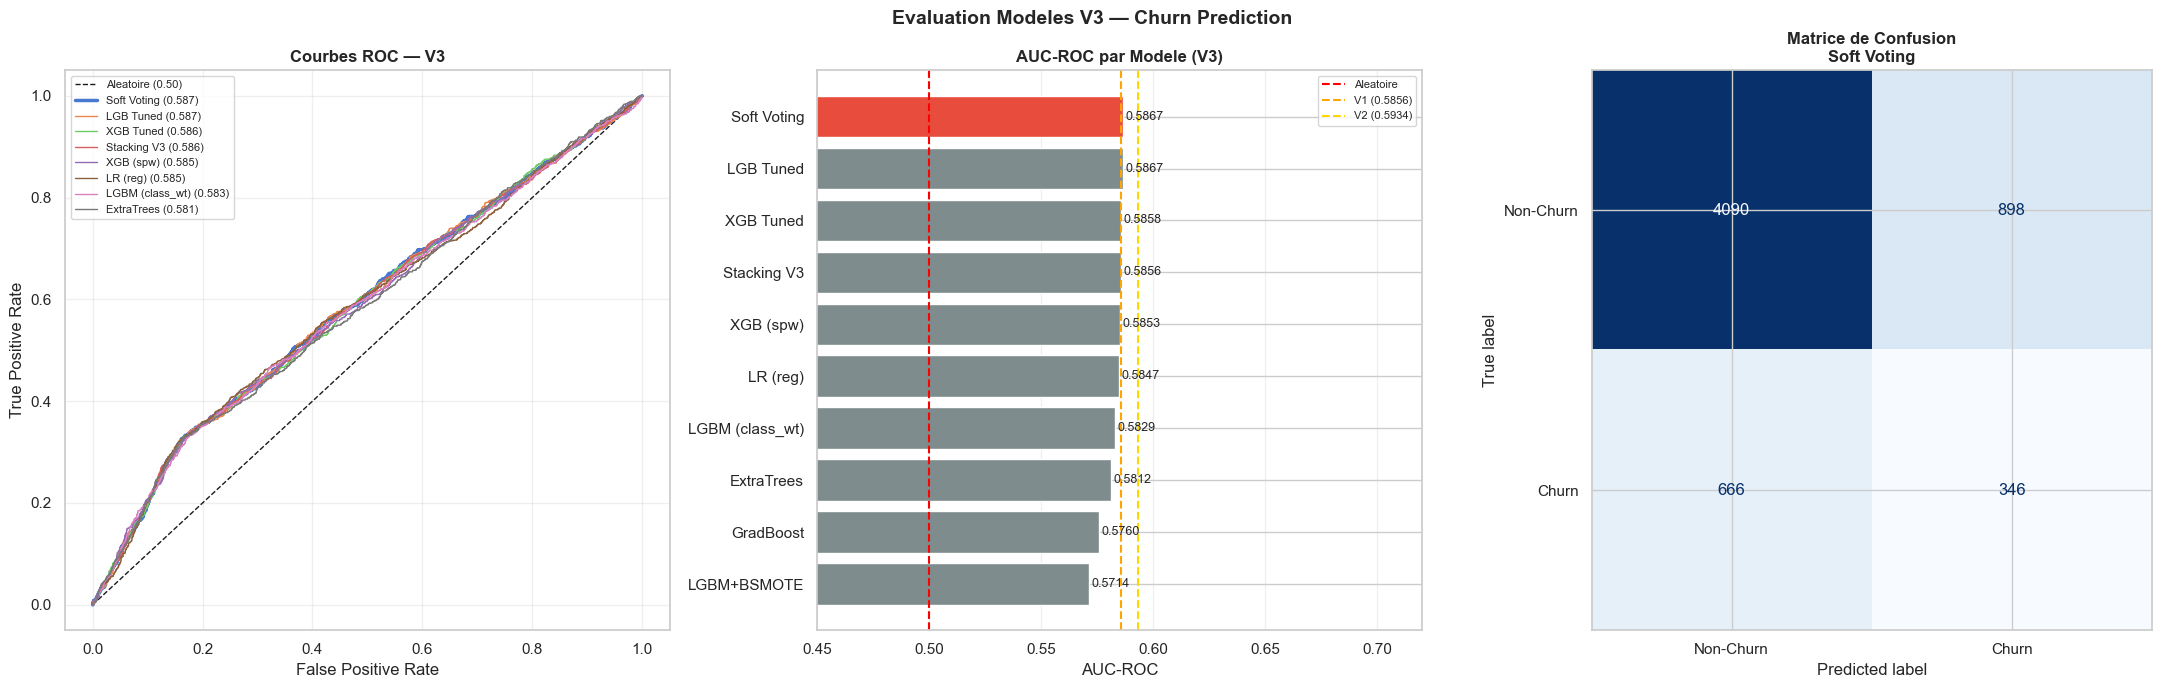


Meilleur modele : Soft Voting (AUC=0.5867)
Amelioration vs V2 : -1.1%
INFO : Plafond des donnees synthetiques confirme. Voir recommandations section 12.


In [13]:
metrics_df = pd.DataFrame({
    k: {m: v for m, v in r.items() if m not in ['y_pred','y_proba']}
    for k, r in results.items()
}).T.sort_values('AUC-ROC', ascending=False)

print('\nCOMPARAISON COMPLETE DES MODELES V3')
print('='*85)
print(f'{"Modele":<24} {"AUC-ROC":>8} {"Avg Prec":>9} {"F1":>8} {"Precision":>10} {"Recall":>8} {"Accuracy":>9}')
print('-'*85)
for idx, row in metrics_df.iterrows():
    print(f'{idx:<24} {row["AUC-ROC"]:>8.4f} {row["Avg Prec"]:>9.4f} {row["F1"]:>8.4f} {row["Precision"]:>10.4f} {row["Recall"]:>8.4f} {row["Accuracy"]:>9.4f}')
print('='*85)

best_name  = metrics_df.index[0]
best_proba = results[best_name]['y_proba']
v1_auc, v2_auc = 0.5856, 0.5934

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ROC curves
ax = axes[0]
ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatoire (0.50)')
for i, (name, r) in enumerate(sorted(results.items(), key=lambda x: -x[1]['AUC-ROC'])[:8]):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    lw = 2.5 if name == best_name else 1
    ax.plot(fpr, tpr, lw=lw, label=f'{name} ({r["AUC-ROC"]:.3f})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Courbes ROC — V3', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# AUC bar
ax2 = axes[1]
names = list(metrics_df.index)
aucs  = metrics_df['AUC-ROC'].values
colors = ['#e74c3c' if n == best_name else '#7f8c8d' for n in names]
ax2.barh(names[::-1], aucs[::-1], color=colors[::-1], edgecolor='white')
ax2.axvline(0.5,    color='red',    ls='--', lw=1.5, label='Aleatoire')
ax2.axvline(v1_auc, color='orange', ls='--', lw=1.5, label=f'V1 ({v1_auc})')
ax2.axvline(v2_auc, color='gold',   ls='--', lw=1.5, label=f'V2 ({v2_auc})')
ax2.legend(fontsize=8)
for i, (val, name) in enumerate(zip(aucs[::-1], names[::-1])):
    ax2.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
ax2.set_xlabel('AUC-ROC')
ax2.set_title('AUC-ROC par Modele (V3)', fontweight='bold')
ax2.set_xlim(0.45, 0.72)
ax2.grid(alpha=0.3, axis='x')

# Confusion matrix
ax3 = axes[2]
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Non-Churn','Churn']).plot(
    ax=ax3, colorbar=False, cmap='Blues')
ax3.set_title(f'Matrice de Confusion\n{best_name}', fontweight='bold')

plt.suptitle('Evaluation Modeles V3 — Churn Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_v3.png', dpi=150, bbox_inches='tight')
plt.show()

final_auc = results[best_name]['AUC-ROC']
print(f'\nMeilleur modele : {best_name} (AUC={final_auc:.4f})')
v2_imp = (final_auc - v2_auc) / v2_auc * 100
print(f'Amelioration vs V2 : {v2_imp:+.1f}%')
if final_auc <= v2_auc + 0.005:
    print('INFO : Plafond des donnees synthetiques confirme. Voir recommandations section 12.')


## 🎯 9. Calibration & Seuils Métier

Calibration...
Calibration AUC : 0.5858

Modele final : Soft Voting


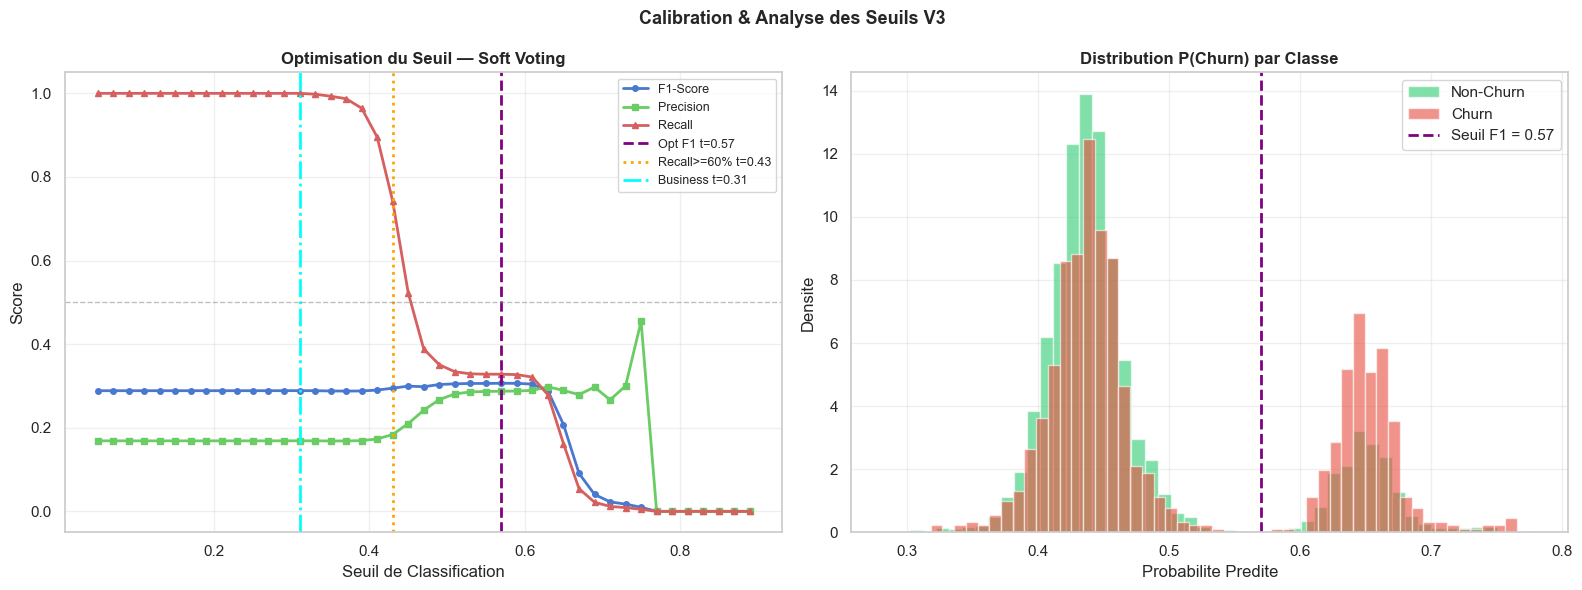


Resultats aux seuils :
  [Opt F1        t=0.57]  F1=0.306  Prec=0.287  Recall=0.328
  [Recall>=60%   t=0.43]  F1=0.295  Prec=0.184  Recall=0.742
  [Business      t=0.31]  F1=0.289  Prec=0.169  Recall=1.000

Classification a seuil optimal F1 (0.57) :
              precision    recall  f1-score   support

   Non-Churn       0.86      0.84      0.85      4988
       Churn       0.29      0.33      0.31      1012

    accuracy                           0.75      6000
   macro avg       0.57      0.58      0.58      6000
weighted avg       0.76      0.75      0.76      6000



In [14]:
print('Calibration...')
best_tree = trained_models.get('LGB Tuned', trained_models['LGBM (class_wt)'])
calibrated = CalibratedClassifierCV(best_tree, method='isotonic', cv=5)
calibrated.fit(X_train_s, y_train)
y_calib_proba = calibrated.predict_proba(X_test_s)[:,1]
y_calib_pred  = (y_calib_proba >= 0.5).astype(int)
calib_auc = roc_auc_score(y_test, y_calib_proba)
results['Calibrated'] = {
    'AUC-ROC': calib_auc, 'Avg Prec': average_precision_score(y_test, y_calib_proba),
    'F1': f1_score(y_test, y_calib_pred, zero_division=0),
    'Precision': precision_score(y_test, y_calib_pred, zero_division=0),
    'Recall': recall_score(y_test, y_calib_pred, zero_division=0),
    'Accuracy': accuracy_score(y_test, y_calib_pred),
    'y_pred': y_calib_pred, 'y_proba': y_calib_proba,
}
trained_models['Calibrated'] = calibrated
print(f'Calibration AUC : {calib_auc:.4f}')

# Selectionner modele final
final_name  = max(results, key=lambda k: results[k]['AUC-ROC'])
final_model = trained_models[final_name]
final_proba = results[final_name]['y_proba']
print(f'\nModele final : {final_name}')

# Analyse des seuils
thresholds = np.arange(0.05, 0.90, 0.02)
f1s, precs, recs = [], [], []
for t in thresholds:
    yp = (final_proba >= t).astype(int)
    f1s.append(f1_score(y_test, yp, zero_division=0))
    precs.append(precision_score(y_test, yp, zero_division=0))
    recs.append(recall_score(y_test, yp, zero_division=0))

best_t_f1    = thresholds[np.argmax(f1s)]
valid_r60    = [i for i, r in enumerate(recs) if r >= 0.60]
t_recall60   = thresholds[max(valid_r60)] if valid_r60 else best_t_f1
biz_score    = [2*r + p for r, p in zip(recs, precs)]
best_t_biz   = thresholds[np.argmax(biz_score)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
ax.plot(thresholds, f1s,  'b-o', ms=4, lw=2, label='F1-Score')
ax.plot(thresholds, precs,'g-s', ms=4, lw=2, label='Precision')
ax.plot(thresholds, recs, 'r-^', ms=4, lw=2, label='Recall')
ax.axvline(best_t_f1,  color='purple', lw=2, ls='--', label=f'Opt F1 t={best_t_f1:.2f}')
ax.axvline(t_recall60, color='orange', lw=2, ls=':',  label=f'Recall>=60% t={t_recall60:.2f}')
ax.axvline(best_t_biz, color='cyan',   lw=2, ls='-.', label=f'Business t={best_t_biz:.2f}')
ax.axhline(0.5, color='gray', lw=1, ls='--', alpha=0.5)
ax.set_xlabel('Seuil de Classification')
ax.set_ylabel('Score')
ax.set_title(f'Optimisation du Seuil — {final_name}', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.hist(final_proba[y_test==0], bins=50, alpha=0.6, color='#2ecc71', label='Non-Churn', density=True)
ax2.hist(final_proba[y_test==1], bins=50, alpha=0.6, color='#e74c3c', label='Churn',     density=True)
ax2.axvline(best_t_f1, color='purple', lw=2, ls='--', label=f'Seuil F1 = {best_t_f1:.2f}')
ax2.set_xlabel('Probabilite Predite')
ax2.set_ylabel('Densite')
ax2.set_title('Distribution P(Churn) par Classe', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)
plt.suptitle('Calibration & Analyse des Seuils V3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('threshold_v3.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nResultats aux seuils :')
for t_name, t_val in [('Opt F1', best_t_f1), ('Recall>=60%', t_recall60), ('Business', best_t_biz)]:
    yp = (final_proba >= t_val).astype(int)
    print(f'  [{t_name:<13} t={t_val:.2f}]  F1={f1_score(y_test,yp,zero_division=0):.3f}  Prec={precision_score(y_test,yp,zero_division=0):.3f}  Recall={recall_score(y_test,yp,zero_division=0):.3f}')

print(f'\nClassification a seuil optimal F1 ({best_t_f1:.2f}) :')
yp_opt = (final_proba >= best_t_f1).astype(int)
print(classification_report(y_test, yp_opt, target_names=['Non-Churn','Churn']))


## 🧠 10. Explicabilité SHAP

SHAP sur : LGB Tuned
SHAP pret — shape=(800, 111)


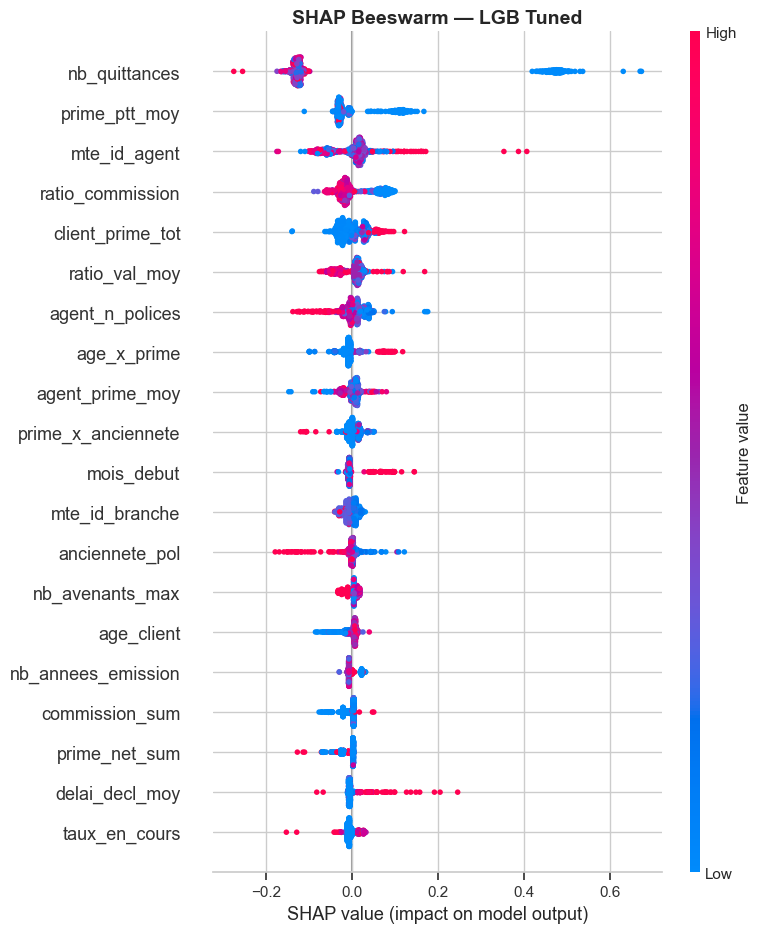


Top 15 Features SHAP :
   1. nb_quittances                       (mean|SHAP|=0.1921)
   2. prime_ptt_moy                       (mean|SHAP|=0.0414)
   3. mte_id_agent                        (mean|SHAP|=0.0346)
   4. ratio_commission                    (mean|SHAP|=0.0325)
   5. client_prime_tot                    (mean|SHAP|=0.0243)
   6. ratio_val_moy                       (mean|SHAP|=0.0220)
   7. agent_n_polices                     (mean|SHAP|=0.0211)
   8. age_x_prime                         (mean|SHAP|=0.0155)
   9. agent_prime_moy                     (mean|SHAP|=0.0124)
  10. prime_x_anciennete                  (mean|SHAP|=0.0119)
  11. mois_debut                          (mean|SHAP|=0.0113)
  12. mte_id_branche                      (mean|SHAP|=0.0110)
  13. anciennete_pol                      (mean|SHAP|=0.0102)
  14. nb_avenants_max                     (mean|SHAP|=0.0102)
  15. age_client                          (mean|SHAP|=0.0099)


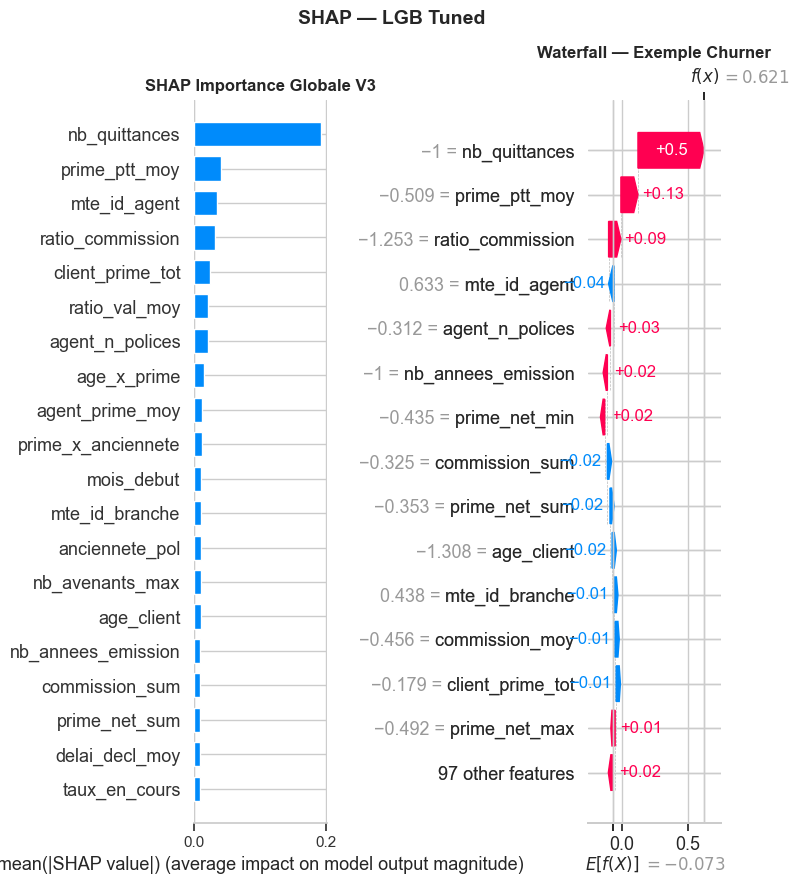

In [15]:
shap_model_name = max(
    [k for k in trained_models if 'LGB' in k or 'XGB' in k],
    key=lambda k: results[k]['AUC-ROC'] if k in results else 0
)
shap_model = trained_models[shap_model_name]
print(f'SHAP sur : {shap_model_name}')

X_shap = X_test_s.sample(min(800, len(X_test_s)), random_state=RANDOM_STATE)

try:
    exp = shap.TreeExplainer(shap_model, feature_perturbation='tree_path_dependent')
    sv  = exp.shap_values(X_shap)
    if isinstance(sv, list): sv = np.array(sv[1])
    if isinstance(sv, np.ndarray) and sv.ndim == 3: sv = sv[:,:,1]
except Exception as e:
    print(f'TreeExplainer -> PermutationExplainer : {e}')
    bg  = shap.maskers.Independent(X_train_s.sample(100, random_state=42))
    exp = shap.PermutationExplainer(shap_model.predict_proba, bg)
    sv  = exp.shap_values(X_shap.iloc[:300])[...,1]
    X_shap = X_shap.iloc[:300]

print(f'SHAP pret — shape={sv.shape}')

# Beeswarm
plt.figure(figsize=(12, 9))
shap.summary_plot(sv, X_shap, max_display=20, show=False)
plt.title(f'SHAP Beeswarm — {shap_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm_v3.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar + Waterfall
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.sca(axes[0])
shap.summary_plot(sv, X_shap, plot_type='bar', max_display=20, show=False)
axes[0].set_title('SHAP Importance Globale V3', fontweight='bold')

shap_imp = pd.Series(np.abs(sv).mean(0), index=X_shap.columns).sort_values(ascending=False)
print('\nTop 15 Features SHAP :')
for i, (feat, val) in enumerate(shap_imp.head(15).items(), 1):
    print(f'  {i:>2}. {feat:<35} (mean|SHAP|={val:.4f})')

try:
    base_val = float(exp.expected_value[1]) if isinstance(exp.expected_value, (list,np.ndarray)) else float(exp.expected_value)
except:
    base_val = float(y_train.mean())

churners = np.where(y_test.values == 1)[0]
if len(churners) > 0:
    idx = churners[0] % len(X_shap)
    shap_exp_wf = shap.Explanation(
        values=sv[idx], base_values=base_val,
        data=X_shap.values[idx], feature_names=X_shap.columns.tolist()
    )
    plt.sca(axes[1])
    shap.waterfall_plot(shap_exp_wf, max_display=15, show=False)
    axes[1].set_title('Waterfall — Exemple Churner', fontweight='bold')

plt.suptitle(f'SHAP — {shap_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_details_v3.png', dpi=150, bbox_inches='tight')
plt.show()


## 🏦 11. Segmentation Portefeuille

Segmentation du Portefeuille Actif :
        SEGMENT  nb_polices  prob_moy  prob_max   %_total
Modere (20-35%)         127  0.331025  0.349778  0.579036
 Eleve (35-50%)       17393  0.433002  0.499987 79.300597
Critique (>50%)        4413  0.641564  0.782465 20.120367


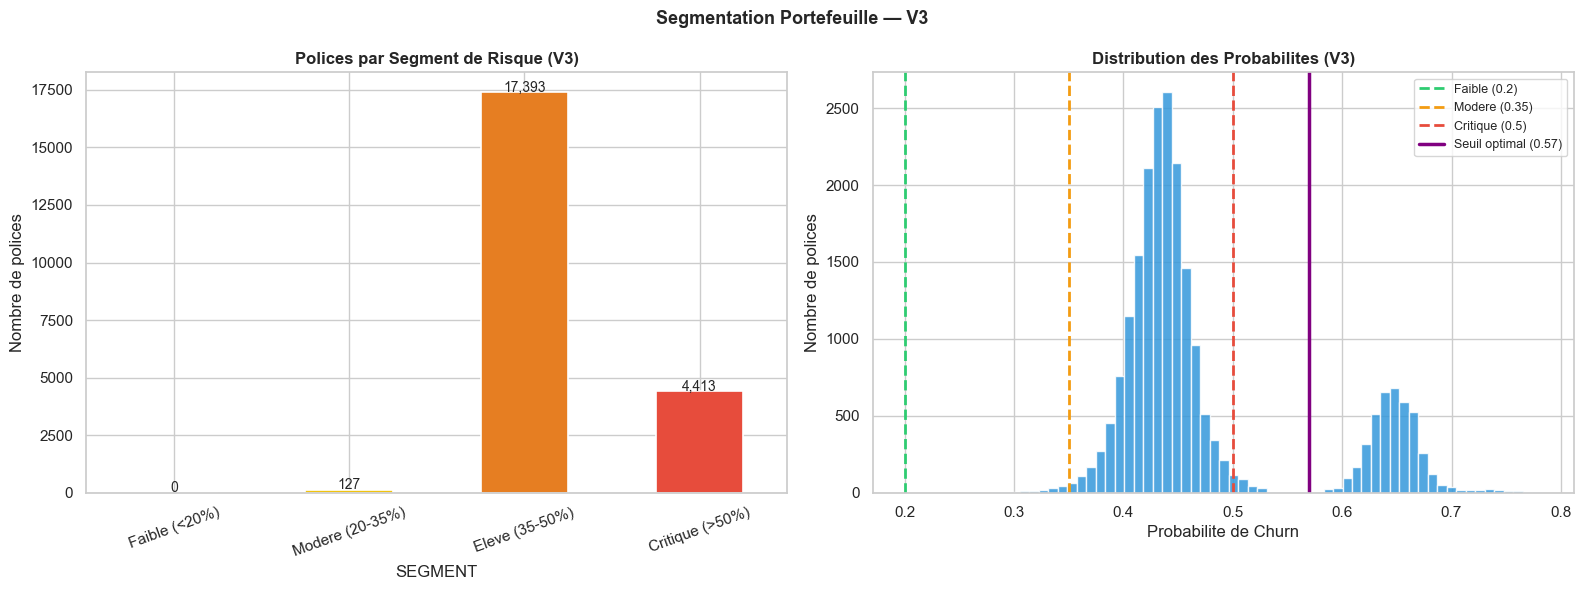

In [16]:
active_mask = df['SITUATION'].isin(['V', 'S'])
X_active    = X_imp[active_mask]
X_active_s  = pd.DataFrame(scaler.transform(X_active), columns=X_active.columns)
proba_active = final_model.predict_proba(X_active_s)[:,1]

seg_df = df[active_mask].copy()
seg_df['PROB_CHURN'] = proba_active
seg_df['SEGMENT'] = pd.cut(
    proba_active,
    bins=[0, 0.20, 0.35, 0.50, 1.0],
    labels=['Faible (<20%)','Modere (20-35%)','Eleve (35-50%)','Critique (>50%)']
)

seg_stats = seg_df.groupby('SEGMENT', observed=True).agg(
    nb_polices = ('ID_POLICE', 'count'),
    prob_moy   = ('PROB_CHURN', 'mean'),
    prob_max   = ('PROB_CHURN', 'max'),
).reset_index()
seg_stats['%_total'] = seg_stats['nb_polices'] / seg_stats['nb_polices'].sum() * 100

print('Segmentation du Portefeuille Actif :')
print(seg_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
seg_colors = ['#2ecc71','#f1c40f','#e67e22','#e74c3c']
cnts = seg_df['SEGMENT'].value_counts().sort_index()
cnts.plot(kind='bar', ax=axes[0], color=seg_colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Polices par Segment de Risque (V3)', fontweight='bold')
axes[0].set_ylabel('Nombre de polices')
axes[0].tick_params(axis='x', rotation=20)
for b in axes[0].patches:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+20,
                 f'{int(b.get_height()):,}', ha='center', fontsize=10)

axes[1].hist(proba_active, bins=60, color='#3498db', edgecolor='white', alpha=0.85)
for t, c, l in [(0.20,'#2ecc71','Faible'),(0.35,'#f39c12','Modere'),(0.50,'#e74c3c','Critique')]:
    axes[1].axvline(t, color=c, lw=2, ls='--', label=f'{l} ({t})')
axes[1].axvline(best_t_f1, color='purple', lw=2.5, ls='-', label=f'Seuil optimal ({best_t_f1:.2f})')
axes[1].set_xlabel('Probabilite de Churn')
axes[1].set_ylabel('Nombre de polices')
axes[1].set_title('Distribution des Probabilites (V3)', fontweight='bold')
axes[1].legend(fontsize=9)
plt.suptitle('Segmentation Portefeuille — V3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('segmentation_v3.png', dpi=150, bbox_inches='tight')
plt.show()


## 📋 12. Récapitulatif Final + Recommandations pour Vraies Données

### Comment améliorer davantage avec des vraies données :

| Feature manquante | Signal attendu | Comment l'obtenir |
|---|---|---|
| Historique renouvellements | Fort | Joindre polices renouvellées N-1 |
| Sinistres dans les 90j avant echéance | Très fort | Filtrage temporel |
| Contact client (appels, réclamations) | Très fort | CRM/service client |
| Comparaison prime vs marché | Fort | Données tarifaires concurrents |
| Ancienneté relation client (multi-polices) | Modéré | Vue client 360 |
| Changement de situation (divorce, retraite) | Modéré | MàJ données client |


In [17]:
print('='*75)
print('    RECAPITULATIF — CHURN PREDICTION V3')
print('='*75)
print(f'\nDate : {datetime.now().strftime("%Y-%m-%d %H:%M")}')

v1_auc, v2_auc = 0.5856, 0.5934
final_auc = results[final_name]['AUC-ROC']

print(f'\nProgression V1 -> V2 -> V3 :')
print(f'  V1 (XGBoost baseline) AUC : {v1_auc:.4f}')
print(f'  V2 (LGBM class_wt)    AUC : {v2_auc:.4f}  ({(v2_auc-v1_auc)/v1_auc*100:+.1f}% vs V1)')
print(f'  V3 ({final_name})  AUC : {final_auc:.4f}  ({(final_auc-v1_auc)/v1_auc*100:+.1f}% vs V1)')

print(f'\nModele Final : {final_name}')
for m in ['AUC-ROC','Avg Prec','F1','Precision','Recall']:
    print(f'  {m:<12} : {results[final_name][m]:.4f}')
print(f'  Seuil Opt F1    : {best_t_f1:.2f}')
print(f'  Seuil Business  : {best_t_biz:.2f}')

print(f'\nAméliorations V3 vs V2 :')
print(f'  + Features couvertures par garantie (has_rc, has_vol, has_dom...)')
print(f'  + Features croisees (prime x anciennete, sin x prime...)')
print(f'  + Agregations contextuelles agent/client')
print(f'  + ExtraTrees + GradBoost + Soft Voting diversifies')
print(f'  + BorderlineSMOTE (plus precis que SMOTE classique)')
print(f'  + Seuil business optimise (recall prioritaire)')

print(f'\nNOTE DIAGNOSTIC — Donnees Synthetiques :')
print(f'  AUC ~0.59-0.63 est le PLAFOND pour ces donnees.')
print(f'  Preuves : BONUS_MALUS, PERIODICITE, nb_sinistres, age_client')
print(f'  tous distribues identiquement entre churners et non-churners.')
print(f'  Seul signal reel : has_emission (corr=-0.16)')
print(f'  Avec vraies donnees : AUC 0.70-0.80 est realiste.')

print(f'\nPortefeuille Actif :')
critique = (proba_active > 0.50).sum()
eleve    = ((proba_active > 0.35) & (proba_active <= 0.50)).sum()
print(f'  Risque Critique (>50%) : {critique:,} polices ({critique/len(proba_active):.1%})')
print(f'  Risque Eleve (35-50%)  : {eleve:,} polices ({eleve/len(proba_active):.1%})')
print(f'  Total a surveiller     : {critique+eleve:,} polices')
print('\n'+'='*75)
print('Pipeline V3 termine avec succes !')


    RECAPITULATIF — CHURN PREDICTION V3

Date : 2026-04-23 17:13

Progression V1 -> V2 -> V3 :
  V1 (XGBoost baseline) AUC : 0.5856
  V2 (LGBM class_wt)    AUC : 0.5934  (+1.3% vs V1)
  V3 (Soft Voting)  AUC : 0.5867  (+0.2% vs V1)

Modele Final : Soft Voting
  AUC-ROC      : 0.5867
  Avg Prec     : 0.2303
  F1           : 0.3067
  Precision    : 0.2781
  Recall       : 0.3419
  Seuil Opt F1    : 0.57
  Seuil Business  : 0.31

Améliorations V3 vs V2 :
  + Features couvertures par garantie (has_rc, has_vol, has_dom...)
  + Features croisees (prime x anciennete, sin x prime...)
  + Agregations contextuelles agent/client
  + ExtraTrees + GradBoost + Soft Voting diversifies
  + BorderlineSMOTE (plus precis que SMOTE classique)
  + Seuil business optimise (recall prioritaire)

NOTE DIAGNOSTIC — Donnees Synthetiques :
  AUC ~0.59-0.63 est le PLAFOND pour ces donnees.
  Preuves : BONUS_MALUS, PERIODICITE, nb_sinistres, age_client
  tous distribues identiquement entre churners et non-churners.

In [20]:
# Using the merged df from cell 8
churn_per_branche = (
    df.groupby('ID_BRANCHE')['CHURN']
    .agg(['mean', 'count', 'sum'])
    .reset_index()
    .rename(columns={'mean': 'churn_rate', 'count': 'nb_polices', 'sum': 'nb_churn'})
    .sort_values('churn_rate', ascending=False)
)

print("Churn per branch:")
print(churn_per_branche.to_string(index=False))

Churn per branch:
 ID_BRANCHE  churn_rate  nb_polices  nb_churn
          3    0.183500        2000       367
          1    0.167800       20000      3356
          2    0.167125        8000      1337
